# 02 — Preprocessing Dev

Goals:
- Experiment with universal preprocessing (high-pass, normalization, segmentation).
- Compare classical features (MFCC, spectral, temporal, chroma).
- Inspect neural log-mel spectrograms and deltas.
- Try augmentation settings on representative clips.

This notebook mirrors the preprocessing pipeline used by the training scripts and follows the project Code Plan.

In [1]:
import os, sys, json, yaml, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
from scipy.signal import butter, sosfilt
sns.set_context('talk'); sns.set_style('whitegrid')




## Load config and utility paths

In [2]:
def detect_root():
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for p in candidates:
        if all((p/d).exists() for d in ['config','data','scripts','notebooks']):
            return p
    return cwd
ROOT = detect_root()
CFG_PATH = ROOT / 'config' / 'config.yaml'
print('ROOT:', ROOT)
cfg = yaml.safe_load(open(CFG_PATH,'r'))
dcfg = cfg.get('config', {})
pcfg = cfg.get('preprocessing', {})
classes = dcfg.get('classes', [])
raw_dir = ROOT / dcfg.get('raw_dir','data/raw')
processed_dir = ROOT / dcfg.get('processed_dir','data/processed')
sr = int(dcfg.get('sample_rate',16000))
duration = float(dcfg.get('duration',1.0))
overlap = float(dcfg.get('overlap',0.0))
univ = pcfg.get('universal',{})
normalize_method = univ.get('normalize_method','peak').lower()
highpass_cutoff = float(univ.get('highpass_cutoff',0.0))
neural = pcfg.get('neural',{})
n_mels = int(neural.get('n_mels',40))
n_fft = int(neural.get('n_fft',512))
hop_length = int(neural.get('hop_length',160))
win_length = int(neural.get('win_length',400))
include_deltas = bool(neural.get('include_deltas',True))
include_delta_deltas = bool(neural.get('include_delta_deltas',False))
print('Classes:', classes)


ROOT: /Users/harryirving/Development/projects/ai-ml/BikeAIv3
Classes: ['angle_grinder', 'background_noise', 'power_tools']


## Helper functions (mirror pipeline)

In [3]:
def butter_highpass(cutoff, sr, order=4):
    nyq = 0.5*sr; norm = max(1e-6, cutoff/nyq)
    from scipy.signal import butter
    return butter(order, norm, btype='highpass', output='sos')
def apply_highpass(y, sr, cutoff):
    if cutoff<=0: return y
    sos = butter_highpass(cutoff, sr)
    return sosfilt(sos, y).astype(np.float32)
def peak_normalize(y, peak=0.99):
    m = np.max(np.abs(y))+1e-12
    return (y/m*peak).astype(np.float32)
def rms_normalize(y, target_db=-20.0):
    target_rms = 10**(target_db/20.0)
    rms = np.sqrt(np.mean(y**2)+1e-12)
    return (y*(target_rms/rms)).astype(np.float32)
def normalize_audio(y, method):
    return rms_normalize(y) if method=='rms' else peak_normalize(y)
def segment_audio(y, sr, duration, overlap):
    seg_len = int(duration*sr); hop = max(1,int(seg_len*(1.0-overlap)))
    if seg_len<=0: return []
    if len(y)<seg_len:
        out = np.zeros(seg_len, dtype=np.float32); out[:len(y)] = y; return [out]
    segs=[]
    for s in range(0, len(y)-seg_len+1, hop): segs.append(y[s:s+seg_len].astype(np.float32))
    if (len(y)-seg_len)%hop!=0:
        pad = np.zeros(seg_len, dtype=np.float32); pad[:len(y[-seg_len:])] = y[-seg_len:]; segs.append(pad)
    return segs


## Pick example files from train manifest

In [8]:
def read_manifest(path: Path):
    pairs = []
    if not path.exists():
        print(f"⚠️ Manifest not found: {path}")
        return pairs
    
    for line in open(path, 'r'):
        line = line.strip()
        if not line:
            continue
        
        # Split on first comma only
        rel, label = line.split(',', 1)
        
        # Build full path: ROOT / 'data' / 'raw' / rel
        # rel is like "angle_grinder/file.mp3"
        full_path = (ROOT / 'data' / 'raw' / rel).resolve()
        
        # Verify file exists
        if not full_path.exists():
            print(f"⚠️ File not found: {full_path}")
            continue
        
        pairs.append((full_path, label))
    
    return pairs

# Load train manifest
train_pairs = read_manifest(ROOT / 'data' / 'splits' / 'train.txt')
print(f'Train files: {len(train_pairs)}')

# Build examples dict
examples = {}
for c in classes:
    for p, l in train_pairs:
        if l == c:
            examples.setdefault(c, []).append(p)
    
    # Keep only first 2 examples per class
    if c in examples:
        examples[c] = examples[c][:2]

# Show what we found
for c, files in examples.items():
    print(f"{c}: {len(files)} example(s)")
    for f in files:
        print(f"  {f}")



Train files: 979
angle_grinder: 2 example(s)
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/angle_grinder/angle-grinder-on-metal-66005.mp3
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/angle_grinder/659926__legand569__using-an-angle-grinderowi.wav
background_noise: 2 example(s)
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/background_noise/chunk_1067.wav
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/background_noise/chunk_923.wav
power_tools: 2 example(s)
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/power_tools/handheld-sander-with-flexible-shaft-grinding-aluminum-320668.mp3
  /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/power_tools/table-circular-saw-300506.mp3


## Visualize preprocessing steps on one file per class


=== Class: angle_grinder ===
File: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/angle_grinder/angle-grinder-on-metal-66005.mp3
Exists: True


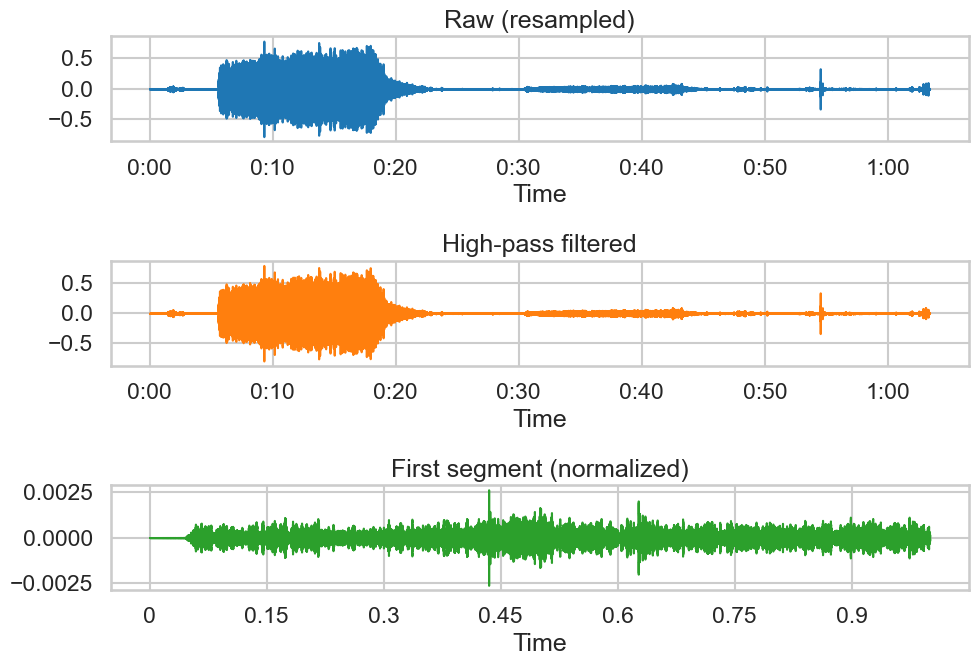


=== Class: background_noise ===
File: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/background_noise/chunk_1067.wav
Exists: True


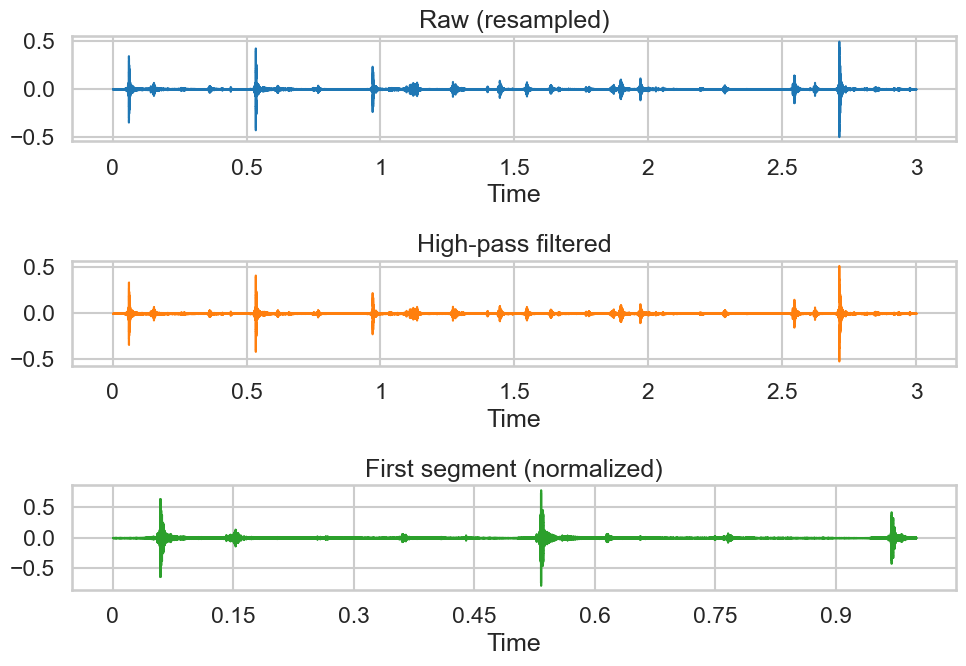


=== Class: power_tools ===
File: /Users/harryirving/Development/projects/ai-ml/BikeAIv3/data/raw/power_tools/handheld-sander-with-flexible-shaft-grinding-aluminum-320668.mp3
Exists: True


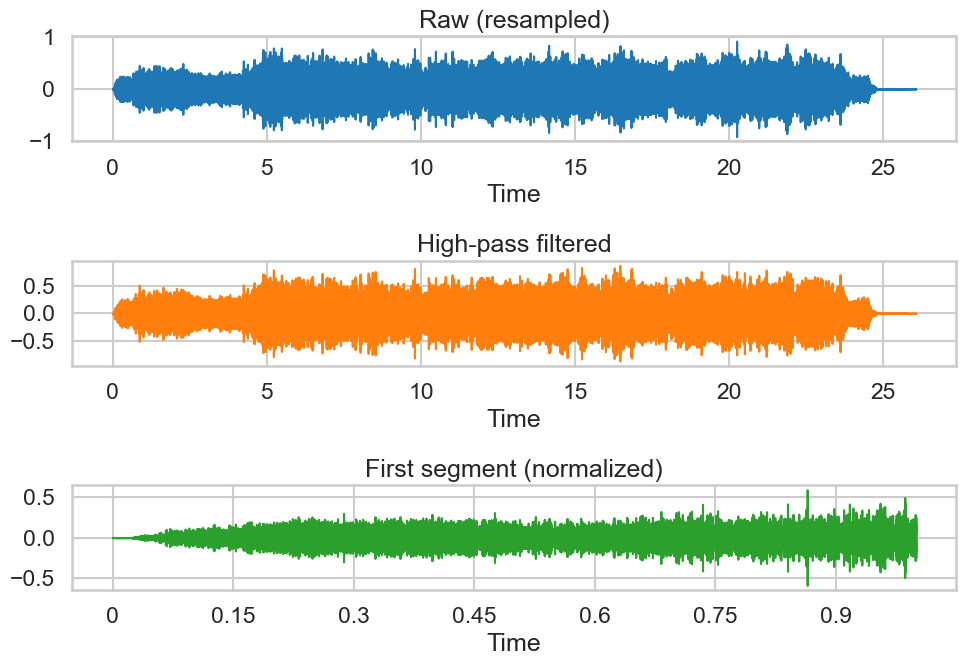

In [9]:
def show_steps(path: Path):
    """Show preprocessing steps for an audio file."""
    try:
        # Load audio
        y, _ = librosa.load(str(path), sr=sr, mono=True)
        
        # Apply preprocessing
        y_hp = apply_highpass(y, sr, highpass_cutoff)
        y_norm = normalize_audio(y_hp, normalize_method)
        segs = segment_audio(y_norm, sr, duration, overlap)
        
        # Plot
        fig, ax = plt.subplots(3, 1, figsize=(10, 7))
        librosa.display.waveshow(y, sr=sr, ax=ax[0], color='C0')
        ax[0].set_title('Raw (resampled)')
        
        librosa.display.waveshow(y_hp, sr=sr, ax=ax[1], color='C1')
        ax[1].set_title('High-pass filtered')
        
        librosa.display.waveshow(segs[0], sr=sr, ax=ax[2], color='C2')
        ax[2].set_title('First segment (normalized)')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error processing {path.name}: {e}")

# Show examples for each class
for c in classes:
    lst = examples.get(c, [])
    if not lst:
        print(f"\nNo examples for {c}")
        continue
    
    file_path = lst[0]
    print(f'\n=== Class: {c} ===')
    print(f'File: {file_path}')
    print(f'Exists: {file_path.exists()}')
    
    show_steps(file_path)




## Classical vs Neural features on a segment

Features for class: angle_grinder
Classical feat dim: (68,)
Neural feat shape [C, n_mels, T]: (2, 40, 101)


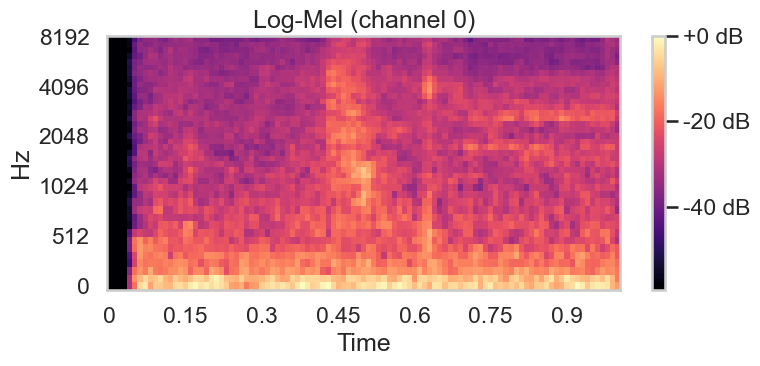

Features for class: background_noise
Classical feat dim: (68,)
Neural feat shape [C, n_mels, T]: (2, 40, 101)


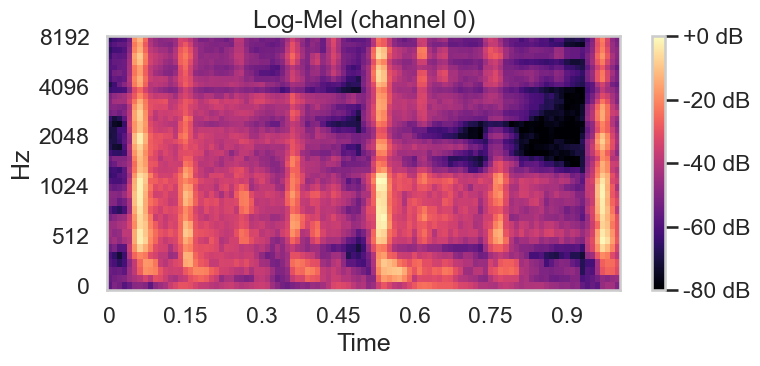

Features for class: power_tools
Classical feat dim: (68,)
Neural feat shape [C, n_mels, T]: (2, 40, 101)


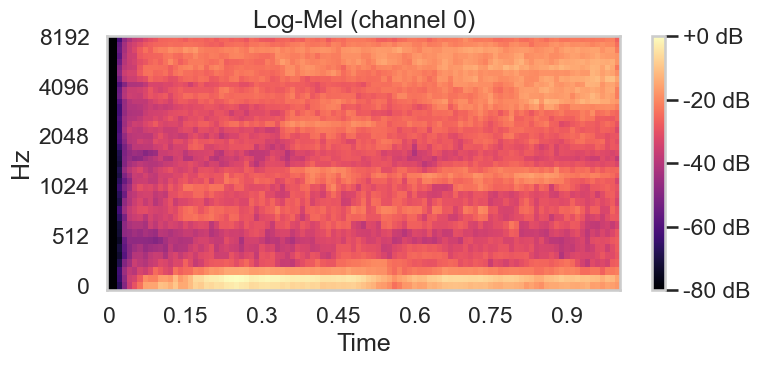

In [10]:
def classical_features(y, sr, cfg_classical):
    n_mfcc = int(cfg_classical.get('n_mfcc', 13))
    n_fft = int(cfg_classical.get('n_fft', 512))
    hop = int(cfg_classical.get('hop_length', 160))
    win = int(cfg_classical.get('win_length', 400))
    include_spectral = bool(cfg_classical.get('include_spectral', True))
    include_temporal = bool(cfg_classical.get('include_temporal', True))
    include_chroma = bool(cfg_classical.get('include_chroma', True))

    feats = []
    mf = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop, win_length=win)
    feats.extend([mf.mean(axis=1), mf.std(axis=1)])

    if include_spectral:
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
        feats.extend([centroid.mean(axis=1), bandwidth.mean(axis=1), rolloff.mean(axis=1)])

    if include_temporal:
        zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=win, hop_length=hop)
        feats.append(zcr.mean(axis=1))

    if include_chroma:
        ch = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
        feats.extend([ch.mean(axis=1), ch.std(axis=1)])

    return np.concatenate(feats, axis=0)


def neural_features(y, sr, cfg_neural):
    n_mels = int(cfg_neural.get('n_mels', 40))
    n_fft = int(cfg_neural.get('n_fft', 512))
    hop = int(cfg_neural.get('hop_length', 160))

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop, n_mels=n_mels, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)
    mats = [S_db]

    if bool(cfg_neural.get('include_deltas', True)):
        d1 = librosa.feature.delta(S_db); mats.append(d1)
        if bool(cfg_neural.get('include_delta_deltas', False)):
            d2 = librosa.feature.delta(S_db, order=2); mats.append(d2)

    return np.stack(mats, axis=0)


def demo_features(path):
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    y = normalize_audio(apply_highpass(y, sr, highpass_cutoff), normalize_method)
    seg = segment_audio(y, sr, duration, overlap)[0]

    cfg_classical = pcfg.get('classical', {})
    cfg_neural = pcfg.get('neural', {})

    cf = classical_features(seg, sr, cfg_classical)
    nf = neural_features(seg, sr, cfg_neural)

    print('Classical feat dim:', cf.shape)
    print('Neural feat shape [C, n_mels, T]:', nf.shape)

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    img = librosa.display.specshow(
        nf[0],
        sr=sr,
        hop_length=int(cfg_neural.get('hop_length', 160)),
        x_axis='time',
        y_axis='mel',
        ax=ax,
    )
    ax.set_title('Log-Mel (channel 0)')
    fig.colorbar(img, ax=ax, format='%+2.f dB')
    plt.tight_layout()
    plt.show()



for c, lst in examples.items():
    if lst:
        print('Features for class:', c)
        demo_features(lst[0])


## Try augmentations on one segment

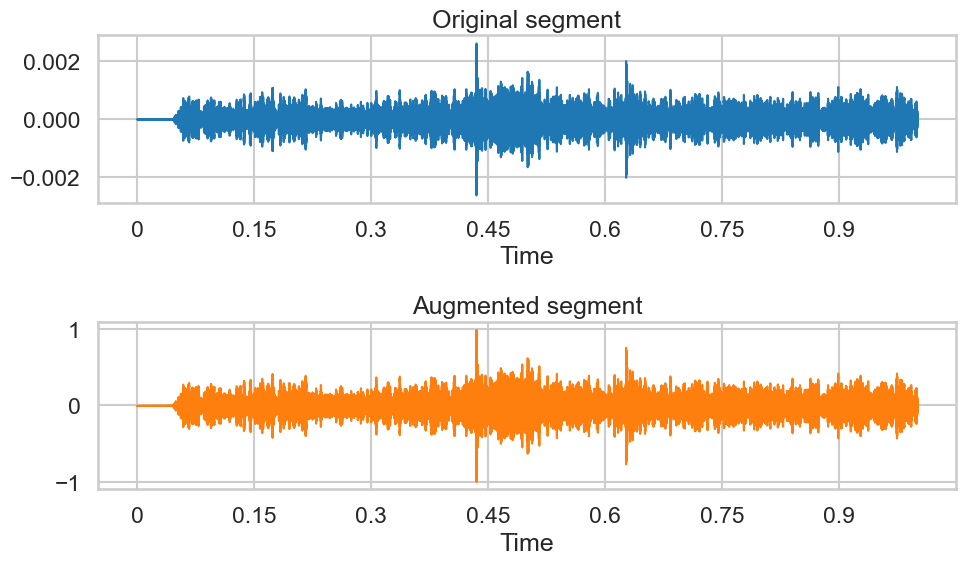

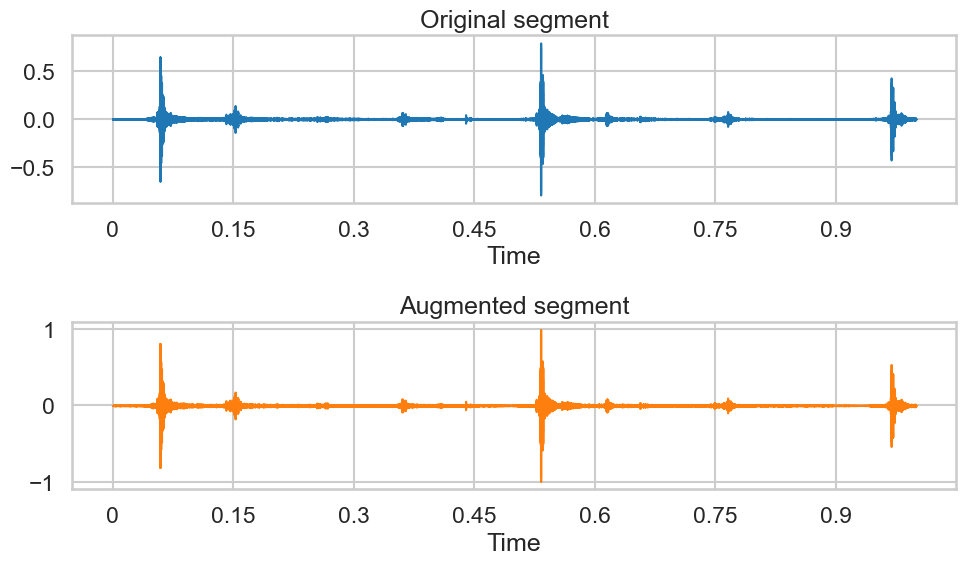

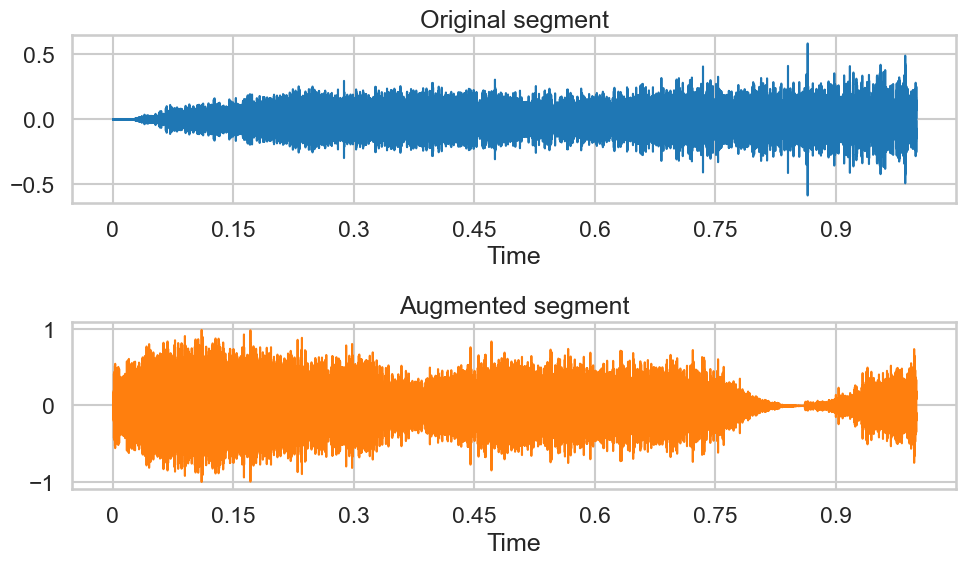

In [11]:
# Pull augmentation and timing params explicitly from previously loaded config dicts
cfg_classical = pcfg.get('classical', {})
cfg_neural = pcfg.get('neural', {})
cfg_aug = pcfg.get('augmentation', {})

# Helper: enforce exact length and normalization after any augmentation
def fix_length_and_norm(y, sr, duration_s, normalize_method):
    segs = segment_audio(y, sr, duration_s, overlap=0.0)
    y_fixed = segs[0] if segs else y
    return normalize_audio(y_fixed, normalize_method)

def aug_once(y, sr, duration_s, normalize_method, cfg_aug):
    out = y.astype(np.float32).copy()

    # Gaussian noise
    g = cfg_aug.get('gaussian_noise', {})
    if g.get('enabled', False) and random.random() < float(g.get('prob', 0.0)):
        amp = np.random.uniform(float(g.get('min_amplitude', 0.001)),
                                float(g.get('max_amplitude', 0.015)))
        out = (out + np.random.normal(0, amp, size=out.shape).astype(np.float32))

    # Time stretch (changes length)
    ts = cfg_aug.get('time_stretch', {})
    if ts.get('enabled', False) and random.random() < float(ts.get('prob', 0.0)):
        rate = np.random.uniform(float(ts.get('min_rate', 0.9)),
                                 float(ts.get('max_rate', 1.1)))
        out = librosa.effects.time_stretch(out, rate=rate)  # length changes [librosa >=0.9]
        out = fix_length_and_norm(out, sr, duration_s, normalize_method)  # enforce target length

    # Pitch shift (length preserved by librosa’s implementation)
    ps = cfg_aug.get('pitch_shift', {})
    if ps.get('enabled', False) and random.random() < float(ps.get('prob', 0.0)):
        semi = np.random.uniform(float(ps.get('min_semitones', -2)),
                                 float(ps.get('max_semitones', 2)))
        out = librosa.effects.pitch_shift(out, sr=sr, n_steps=semi)

    # Time shift (circular)
    sh = cfg_aug.get('time_shift', {})
    if sh.get('enabled', False) and random.random() < float(sh.get('prob', 0.0)):
        frac = np.random.uniform(float(sh.get('min_fraction', -0.3)),
                                 float(sh.get('max_fraction', 0.3)))
        out = np.roll(out, int(len(out) * frac))  # negative or positive OK

    # Gain
    gn = cfg_aug.get('gain', {})
    if gn.get('enabled', False) and random.random() < float(gn.get('prob', 0.0)):
        db = np.random.uniform(float(gn.get('min_gain_db', -6)),
                               float(gn.get('max_gain_db', 6)))
        out = out * (10 ** (db / 20.0))

    # Final enforcement to prevent any drift
    out = fix_length_and_norm(out, sr, duration_s, normalize_method)
    return out.astype(np.float32)

# Demo on one segment per class
for c, lst in examples.items():
    if not lst:
        continue
    p = lst[0]
    y, _ = librosa.load(str(p), sr=sr, mono=True)  # sr must be defined earlier in the notebook
    y = normalize_audio(apply_highpass(y, sr, highpass_cutoff), normalize_method)
    seg = segment_audio(y, sr, duration, overlap)[0]
    aug_seg = aug_once(seg, sr, duration, normalize_method, cfg_aug)

    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    librosa.display.waveshow(seg, sr=sr, ax=ax[0], color="C0"); ax[0].set_title("Original segment")
    librosa.display.waveshow(aug_seg, sr=sr, ax=ax[1], color="C1"); ax[1].set_title("Augmented segment")
    plt.tight_layout(); plt.show()
